In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv(r'D:\IMP  ML  PROJECTS\CAR PRICE PREDICTION\city\MUMBAI\database\cleaned_car_data_Petrol.csv')
df.head()

,Registration Year,Insurance,Seats,Kms Driven,Ownership,Engine Displacement,Mileage,Max_Power_clean,Max_Power_RPM,Max_Torque_Nm,...,Drive Type_RWD,Engine Type_Standard,Engine Type_Standard Brand Engine,Engine Type_Turbocharged,Engine Type_V-Type,Fuel Supply System_Direct Injection,Fuel Supply System_EFI,Fuel Supply System_MPFi,Fuel Supply System_Other,Gross Weight
0,2022.0,0,5.0,30000,1,999,17.20,113.98,5500.0,178.0,...,0,1,0,0,0,1,0,0,0,1660
1,2024.0,2,7.0,8000,1,1451,12.34,141.04,5000.0,250.0,...,0,0,0,1,0,0,0,1,0,165
2,2024.0,0,7.0,20277,1,1482,14.70,157.81,5500.0,253.0,...,0,1,0,0,0,1,0,0,0,165
3,2022.0,2,5.0,20000,1,999,19.17,71.01,6250.0,96.0,...,0,1,0,0,0,0,0,1,0,165
4,2023.0,2,5.0,27802,1,1497,17.70,113.42,6300.0,144.0,...,0,1,0,0,0,0,0,1,0,165


In [3]:
df['Turbo Charger'] = df['Turbo Charger'].fillna(0)

df['Gearbox'] = df['Gearbox'].fillna(df['Gearbox'].mode()[0])

df['Price'] = df['Price'].fillna(df['Price'].mode()[0])

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# 1. Define groups
continuous_features = [
    "Registration Year", "Engine Displacement", "Max_Power_RPM", 
    "Max_Torque_Nm", "Max_Torque_RPM", "Petrol Mileage ARAI", 
    "Petrol Fuel Tank Capacity", "Ground Clearance Unladen", 
    "Wheel Base", "Top Speed", "Volume", "Gross Weight"
]
skewed_features = ["Max_Power_clean", "Kms Driven"]

# 2. Separate Features and Target
X_raw = df.drop(columns=['Price'])
y = df['Price']

# 3. Setup Transformer
log_transformer = FunctionTransformer(np.log1p, validate=True)

preprocessor = ColumnTransformer(
    transformers=[
        # These will replace the old features with cleaned (transformed) ones
        ('log', log_transformer, skewed_features),
        ('num_scaler', StandardScaler(), continuous_features),
    ],
    remainder='passthrough' 
)

# 4. Perform transformation
X_transformed = preprocessor.fit_transform(X_raw)

# 5. Reconstruct as new_df
remaining_cols = [c for c in X_raw.columns if c not in (skewed_features + continuous_features)]
all_col_names = skewed_features + continuous_features + remaining_cols

new_df = pd.DataFrame(X_transformed, columns=all_col_names)

# Final verification
print(f"Total features in new_df: {new_df.shape[1]}")
print(f"Original features count: {X_raw.shape[1]}")

Total features in new_df: 41
Original features count: 41


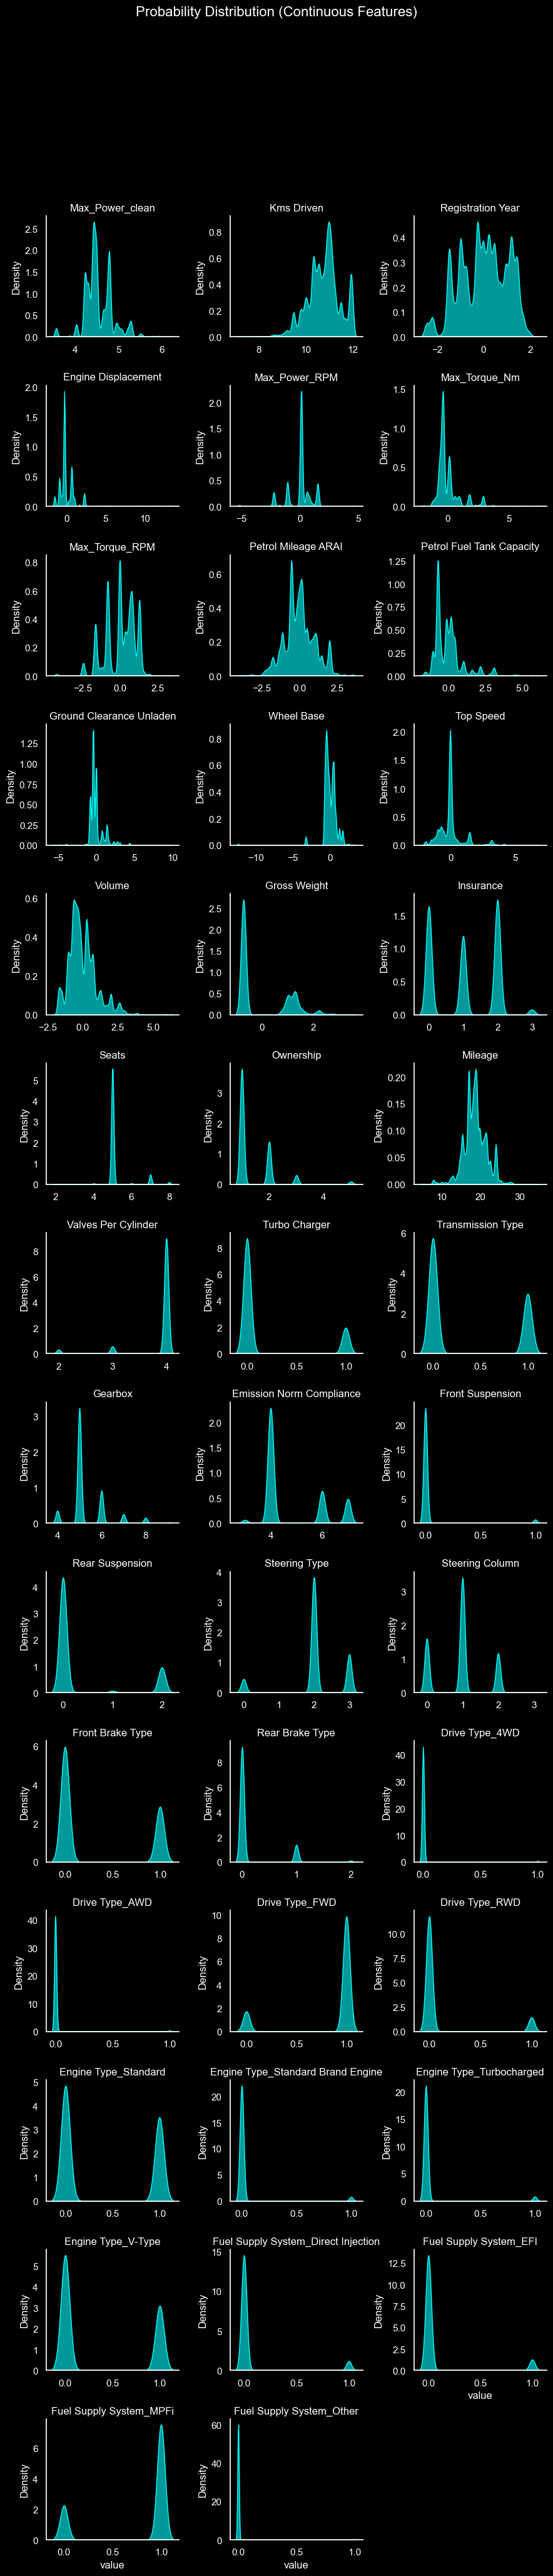

In [17]:
sns.set_theme(style="dark", palette="muted")
plt.style.use('dark_background')

df_melted_cont = new_df.melt()

g = sns.FacetGrid(df_melted_cont, col="variable", col_wrap=3, 
                  sharex=False, sharey=False, despine=True)

g.map(sns.kdeplot, "value", fill=True, color="cyan", bw_adjust=0.5, alpha=0.6)

g.set_titles("{col_name}", color="white", fontsize=12)
plt.subplots_adjust(top=0.9, hspace=0.4)
g.fig.suptitle('Probability Distribution (Continuous Features)', color="white", fontsize=16)

plt.show()

In [18]:
y_log = np.log1p(df['Price'])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(new_df, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid (checking k from 1 to 20)
param_grid = {'n_neighbors': range(1, 21)}

# 2. Initialize the Grid Search with 5-fold cross-validation
knn_grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2')

# 3. Fit to your training data
knn_grid.fit(X_train, y_train)

# 4. Get the best model
best_knn = knn_grid.best_estimator_

print(f"Optimal number of neighbors: {knn_grid.best_params_['n_neighbors']}")

Optimal number of neighbors: 20


In [25]:
y_pred_knn = best_knn.predict(X_test)

# Calculate scores
r2_knn = r2_score(y_test, y_pred_knn)
# Since we used log(price), MAE will be in log units
mae_log = mean_absolute_error(y_test, y_pred_knn)

print(f"kNN R2 Score: {r2_knn}")

kNN R2 Score: 0.0758513313977045


In [26]:
# Check both scores
train_score = best_knn.score(X_train, y_train)
test_score = best_knn.score(X_test, y_test)

print(f"Training R2: {train_score}")
print(f"Test R2: {test_score}")

Training R2: 0.10445904836386954
Test R2: 0.0758513313977045


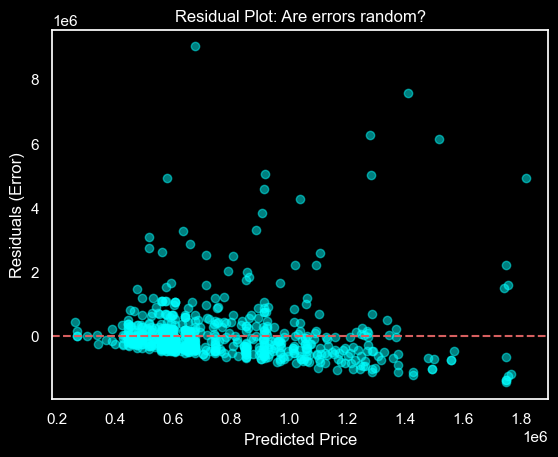

In [28]:
residuals = y_test - y_pred_knn
plt.scatter(y_pred_knn, residuals, alpha=0.5, color='cyan')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot: Are errors random?')
plt.show()